# **Equazioni non lineari**

Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

# **Rappresentazione grafica della funzione**          
Disegnare il grafico della funzione $f$ e la retta $y=0$ in modo da evidenziare le due soluzioni dell'equazione.

In [35]:
# step 0 -> ricordarsi di importare i pacchetti numpy and matplotlib

import numpy as np
import matplotlib.pyplot as plt

Vediamo un nuovo costrutto utile per costruire funzioni matematiche "lambda function" in modo semplice e veloce.


      f = lambda nome_variabili: espressione della funzione

In [36]:
# esempi di lambda function

f = lambda x: x**2
g = lambda t: t**2
h = lambda t,x,y: t+x+y


print("valuto la funzione f in 0.5: %f" % f(0.5))
print("valuto la funzione g in 0.5: %f" % g(0.5))
print("valuto la funzione h in (1,2,3): %f" % h(1, 2, 3))

valuto la funzione f in 0.5: 0.250000
valuto la funzione g in 0.5: 0.250000
valuto la funzione h in (1,2,3): 6.000000


Scrivere la funzione $f$ dell'esercizio usando la lambda function

In [37]:
# lambda function della funzione f

f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1
print("Valuto la funzione f in 0.5: %f" % f(0.5))



Valuto la funzione f in 0.5: -0.080704


Rappresentazione grafica

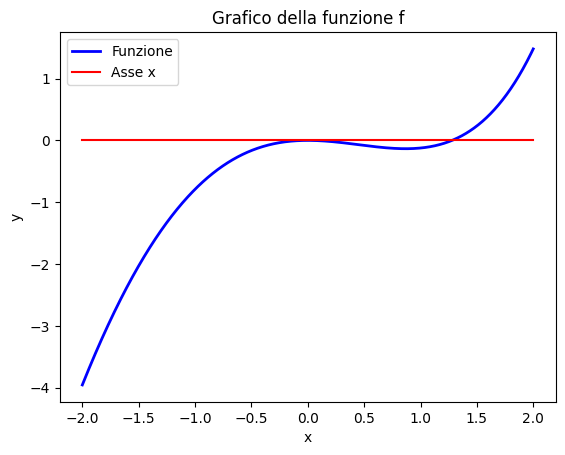

In [38]:
# rappresentazione grafica della funzione f

xgrid = np.linspace(-2,2,1000)
plt.plot (xgrid,f(xgrid), 'b-',linewidth=2.0, label='Funzione')
plt.plot(xgrid, np.zeros(np.shape(xgrid)), 'r',label='Asse x')
plt.legend()
plt.title("Grafico della funzione f")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


# **Bisezione**


<mark>**Domanda:**</mark></br>
 Il metodo di bisezione è applicabile per calcolare
entrambe le radici? Motivare la risposta.



<mark>**Esercizio 1.1: implementazione bisezione**</mark></br>

Scrivere una function $\verb|bisez|$ che implementi il metodo di bisezione. L'intestazione della funzione sarà ad esempio la seguente:


      def bisez(f,a,b,toll):
      #
      # implementazione di bisezione
      #
      return xvect


Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $a→$ primo estremo
* $b→$ secondo estremo
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.




In [39]:
# definzione del metodo di bisezione
def bisez(f, a, b, toll):

  if (f(a)*f(b)>=0):    # verifico che gli estremi siano discordi per applicare teorema degli zeri 
    raise RuntimeError("Errore: a e b non è una bracket")
  
  xvect=[]    # creazione del vettore che con

  while (abs(a-b) > toll):
    
    x = 0.5*(a+b)      # calcolo punto medio 

    if(f(x) == 0):    # verifico se il punto medio è esattamente uno zero 
      xvect.append(x)
      print("x è uno zero")
      break 

    if (f(x)*f(a)>0):
      a = x

    else: 
      b = x

    xvect.append(x)

  return np.array(xvect)




<mark>**Esercizio 1.2**</mark></br>
Quando è possibile, applicare il metodo di bisezione alla funzione $f$.
Stampare il numero di iterazioni, lo zero trovato $x^*$ e il valore della funzione $f(x^*)$.

In [40]:
# scelta degli estremi a,b

a = 1.0

b = 2.0

xvect = bisez(f, a, b, 1e-12)

# stampare il numero di iterazioni effettuato, il valore di x0 e valore di f(x0)
print(f"Numero iterazioni: {len(xvect)}")
print(f"Ultimo valore di x:{xvect[-1]}")
print(f"Ultimo valore di f:{f(xvect[-1]): .0e}")

Numero iterazioni: 40
Ultimo valore di x:1.2797013310018883
Ultimo valore di f: 7e-13


**Alcuni commenti finali sul metodo di bisezione**

Dalla teoria sappiamo che:

*   Il metodo di bisezione è convergente e abbiamo una stima dell'errore (anche senza dover sapere la soluzione esatta)

\begin{equation}
|e^k| \le \frac{1}{2^{k+1}} |b-a| .
\end{equation}

*   Se voglio ottenere una soluzione esatta a meno di una tolleranza $eps$

\begin{equation}
k > \log_2 \frac{|b-a|}{eps} - 1 .
\end{equation}

*   La convergenza del metodo di bisezione è lenta (l'errore non sempre decresce monotonicamente).

*   Se uno zero ha molteplicità dispari, allora vale il teorema degli zeri. Nel caso di molteplicità pari, non è garantito.

# **Metodo di Newton**

<mark>**Domanda:**</mark></br>
Discutere le proprietà  di convergenza del metodo di Newton per
  entrambi gli zeri, valutando l'opportunità  di applicare il metodo
  di Newton.





<mark>**Esercizio 2.1: implementazione Newton**</mark></br>
Scrivere una function $\verb|newton|$ che implementi il metodo di Newton. L'intestazione della funzione sarà ad esempio la seguente:


      def newton (f,df,x0,nmax,toll)
      #
      # implementazione del metodo di newton
      #
      return xvect

Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $\verb|df|→$ la derivata della funzione $f$,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.


In [ ]:
import numpy as np
import warnings   # pacchetto per i warning

# funzione f e la sua derivata df
f = lambda t: np.exp(t) - t**2 - np.sin(t) - 1.0
df = lambda t: np.exp(t) - 2*t - np.cos(t)

x0 = 1.0  # scelto guardando il grafico sopra 
nmax = 100


# definizione del metodo di newton
def newton(f, df, x0, nmax, toll = 1e-6):

  # inizializzazione del vettore delle iterazioni
  iterazione = 0
  errore = toll + 1
  xvect = []
  x_old = x0

  # ciclo iterativo
  while iterazione < nmax and errore > toll:
    
    if abs(df(x_old)) < 1e-15:
      raise RuntimeError(f"Metodo fallito: derivata nulla al passo {iterazione}. Punto attuale: {x_old}")
    
    x_new = x_old - f(x_old)/df(x_old)
    errore = abs(x_old - x_new)
    xvect.append(x_new)
    iterazione += 1
    x_old = x_new

  if errore > toll:
    warnings.warn(f"Raggiunto nmax ({nmax}) senza convergenza. Errore residuo: {errore:.2e}")

  return np.array(xvect), errore


xvect, errore = newton(f, df, x0, nmax)

print (f"Numero di iterazioni: {len(xvect)}")
print (f"Ultimo valore di x: {xvect[-1]}")
print (f"Ultimo valore di f: {f(xvect[-1])}")
print (f"Errore: {errore}")


Numero di iterazioni: 7
Ultimo valore di x: 1.2797013310009966
Ultimo valore di f: 4.440892098500626e-16
Errore: 1.003530591958679e-11


<mark>**Esercizio 2.2: modifica di Newton**</mark></br>
Si scriva, modificando opportunamente la function $\verb|newton|$,
il metodo di Newton modificato, passando come parametro in ingresso anche la molteplicità dello zero cercato. L'intestazione della funzione sarà la seguente:


      def newton (f,df,x0,nmax,toll,m=1)
        #
        # modificare il passo iteratativo di newton
        #  x^{k+1} = x^k - m f(x^k)/f'(x^k)
        #
        return xvect

dove $\verb|m|$ è la molteplicità dello zero cercato.


<mark>**Esercizio 2.3**</mark></br>

Applicare il metodo di Newton e, quando è il caso, il metodo di Newton modificato (aggiungendo la specifica $\verb|m|$) con tolleranza $10^{-6}$, per la funzione
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Riportare su un grafico in scala semilogaritmica l'andamento dell'errore in funzione del numero di iterazioni. Per il calcolo dell'errore si assuma come valore esatto dello zero non nullo, il valore $x=1.279701331000996$. Cosa si osserva nell'ordine di convergenza?


In [42]:
# funzione f e la sua derivata df
f = lambda t: np.exp(t) - t**2 - np.sin(t) - 1.0
df = lambda t: np.exp(t) - 2*t - np.cos(t)

In [43]:
# ricerca dello zero xe=1.279701331000996
xe=1.279701331000996
# starting point
x0=1


    
# calcolo dell'errore

# rappresentazione grafica dell'errore usando plt.semilogy()


In [44]:
# Ricerca dello zero xe=0
xe=0
# starting point
x0=0.1




**Alcuni commenti finali sul metodo di Newton**

Dalla teoria sappiamo che:

*   Il metodo di Newton è (SOLO) localmente convergente
*   Se converge, allora converge quadraticamente per zeri di molteplicità 1, linearmente per zeri di molteplicità superiore (in tal caso occorre Newton modificato per ripristinare convergenza ottimale)
*   Il metodo di Newton è un particolare metodo di punto fisso

# **Esercizi per casa**


## **Metodo punto fisso**

Si consideri il problema della ricerca degli zeri dell'equazione non lineare $g(x)=0$, dove $g$ è definita da:
\begin{equation}
g(x):= 4x-e^{x^2},\qquad x\in\left[0,\frac{3}{2}\right]\;.
\end{equation}


<mark>**Esercizio 3.1**</mark></br>
Disegnare il grafico della funzione $g$ e la retta $y=0$ in modo
da evidenziare le due soluzioni dell'equazione. Inoltre, per ogni soluzione, determinare un opportuno intervallo che la contenga.

In [45]:
# plot della funzione g

**Osservazione sulle soluzioni dell'esercizio 3.1:**

<mark>**Esercizio 3.2**</mark></br>
Individuare la funzione di iterazione $\phi$ per il metodo di punto fisso e la sua derivata $\phi'(x)$. Plottare $\phi'$ nell'intervallo considerato. Il metodo di punto fisso è applicabile per calcolare
entrambe le radici? Motivare la risposta.

In [46]:
# plot della derivata prima di phi

**Motivazione esercizio 3.2:**

<mark>**Esercizio 3.3**</mark></br>

Scrivere la function $\verb|puntofisso|$ che implementi il metodo di punto fisso. L'intestazione della funzione sarà ad esempio la seguente:


      def puntofisso (phi,x0,nmax,toll)
        #
        # implementazione del metodo di newton
        #
        return xvect

Tale funzione riceve in input:
* $\verb|phi|→$ funzione di iterazione,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.

In [47]:
def puntofisso(phi, x0, nmax, toll):


  return

<mark>**Esercizio 3.3**</mark></br>
Applicare il metodo del punto fisso, quando possibile, con numero massimo di iterazioni $\verb|nmax|=100$ e tolleranza pari a
$10^{-5}$, utilizzando la funzione $\verb|puntofisso|$ e dati iniziali $x0=0$, $x0=1.5$.

In [48]:
# verifica del metodo di punto fisso

## **Bisezione**

<mark>**Esercizio 4.1**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

Provare ad implementare bisezione con il ciclo for. Ricordo che il numero massimo di iterazioni è
\begin{equation}
 k > \log_2(\frac{|b-a|}{\text{toll}}) -1
\end{equation}
con $k$ un numero intero. Ricordo che nel caso in cui si ottenga un numero non intero nell'espressione a destra allora $k$ va arrotondato al numero intero superiore. Un comando utile per il calcolo di $k$ è $\verb|np.fix|$ (si veda $\verb|help(np.fix)|$).



In [49]:
def bisezfor(f, a, b, toll):


  return

<mark>**Esercizio 4.2**</mark></br>
Testare la function $\verb|bisezfor|$ nella ricerca degli zeri della funzione $f$.

In [50]:
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
# scelta degli estremi a,b


# stampare iterazioni, valore di x* e valore di f(x*)



## **Bisezione e Newton**
<mark>**Esercizio 5**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Utilizzare in sequenza il metodo di bisezione e il metodo di Newton per la ricerca dello zero $1 < \alpha_2 < 1.5$; in particolare si adotti il metodo di bisezione per l'avvicinamento allo zero e successivamente il metodo di Newton per la
convergenza "veloce" ad $\alpha_2$, assumendo come punto di innesco lo zero approssimato con il metodo di bisezione. Nello specifico si considerino 5 iterazioni del metodo di bisezione sull'intervallo $[1, 1.5]$ e si assuma come tolleranza per il metodo di Newton il valore $10^{-10}$.



In [51]:
# estremi dell'intervallo
a=1
b=1.5
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
df = lambda x: np.exp(x) - 2*x - np.cos(x)


